# Spatial Clustering Analysis - Crime Hotspot Detection

## 🎯 Business Context
Advanced point pattern analysis using density-based clustering and spatial statistics.

**Key Objectives**:
- Apply DBSCAN for crime hotspot identification
- Calculate Nearest Neighbor Index (NNI) for randomness testing
- Implement Ripley's K-function for scale-dependent clustering
- Perform Getis-Ord Gi* hotspot detection
- Analyze spatiotemporal patterns (day vs night)
- Correlate with socioeconomic indicators

**Study Area**: Johannesburg, South Africa

**Applications**: Crime prevention, resource allocation, urban safety

In [1]:
# Import Libraries
import ee
import geemap
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN
from scipy.spatial import ConvexHull
from scipy.spatial.distance import pdist, cdist
from scipy.stats import poisson
import warnings
warnings.filterwarnings('ignore')

try:
    ee.Initialize()
except:
    ee.Authenticate()
    ee.Initialize()

plt.style.use('seaborn-v0_8-whitegrid')
print('✓ Libraries loaded')

✓ Libraries loaded


In [2]:
# Study Area & Generate Synthetic Crime Data
np.random.seed(42)

# Johannesburg bounding box
bbox = {'lon_min': 27.9, 'lon_max': 28.2, 'lat_min': -26.3, 'lat_max': -26.1}

# Generate clustered crime points (3 hotspots + random background)
n_clusters = 3
n_per_cluster = 80
n_background = 50

# Cluster centers
cluster_centers = [
    (28.05, -26.20),  # CBD
    (28.12, -26.18),  # East
    (28.00, -26.25)   # South
]

crime_data = []
for center in cluster_centers:
    cluster_points = np.random.normal(center, [0.01, 0.01], (n_per_cluster, 2))
    for point in cluster_points:
        crime_data.append({
            'lon': point[0],
            'lat': point[1],
            'severity': np.random.choice(['Low', 'Medium', 'High'], p=[0.5, 0.3, 0.2]),
            'time': np.random.choice(['Day', 'Night'], p=[0.4, 0.6])
        })

# Background (random)
for _ in range(n_background):
    crime_data.append({
        'lon': np.random.uniform(bbox['lon_min'], bbox['lon_max']),
        'lat': np.random.uniform(bbox['lat_min'], bbox['lat_max']),
        'severity': np.random.choice(['Low', 'Medium', 'High']),
        'time': np.random.choice(['Day', 'Night'])
    })

crime_df = pd.DataFrame(crime_data)
print(f'Total crime incidents: {len(crime_df)}')
print(crime_df.head())

Total crime incidents: 290
         lon        lat severity   time
0  28.054967 -26.201383   Medium    Day
1  28.056477 -26.184770      Low  Night
2  28.047658 -26.202341   Medium  Night
3  28.065792 -26.192326   Medium  Night
4  28.045305 -26.194574      Low    Day


In [3]:
# DBSCAN Clustering
print('\n=== DBSCAN Clustering ===')

# Prepare coordinates
coords = crime_df[['lon', 'lat']].values

# DBSCAN parameters
eps_km = 1.0  # 1km radius
eps_deg = eps_km / 111  # Convert to degrees
min_samples = 10

db = DBSCAN(eps=eps_deg, min_samples=min_samples, metric='euclidean')
crime_df['cluster'] = db.fit_predict(coords)

# Count clusters
n_clusters_found = len(set(crime_df['cluster'])) - (1 if -1 in crime_df['cluster'] else 0)
n_noise = list(crime_df['cluster']).count(-1)

print(f'Clusters found: {n_clusters_found}')
print(f'Noise points: {n_noise}')
print(f'Clustered points: {len(crime_df) - n_noise}')


=== DBSCAN Clustering ===
Clusters found: 4
Noise points: 62
Clustered points: 228


In [4]:
# Nearest Neighbor Index (NNI)
print('\n=== Nearest Neighbor Analysis ===')

def nearest_neighbor_index(points, area_km2):
    """Calculate NNI to test for randomness."""
    n = len(points)
    
    # Observed mean nearest neighbor distance
    distances = pdist(points)
    dist_matrix = cdist(points, points)
    np.fill_diagonal(dist_matrix, np.inf)
    nn_distances = dist_matrix.min(axis=1) * 111  # to km
    observed_mean = nn_distances.mean()
    
    # Expected mean under CSR (Complete Spatial Randomness)
    density = n / area_km2
    expected_mean = 0.5 / np.sqrt(density)
    
    # NNI
    nni = observed_mean / expected_mean
    
    # Z-score
    se = 0.26136 / np.sqrt(n * density)
    z = (observed_mean - expected_mean) / se
    
    return {
        'observed': observed_mean,
        'expected': expected_mean,
        'nni': nni,
        'z_score': z
    }

area_km2 = ((bbox['lon_max'] - bbox['lon_min']) * 111) * ((bbox['lat_max'] - bbox['lat_min']) * 111)
nni_result = nearest_neighbor_index(coords, area_km2)

print(f"Observed NN Distance: {nni_result['observed']:.3f} km")
print(f"Expected NN Distance: {nni_result['expected']:.3f} km")
print(f"NNI: {nni_result['nni']:.3f}")
print(f"Z-Score: {nni_result['z_score']:.2f}")

if nni_result['nni'] < 1:
    print('Pattern: CLUSTERED (NNI < 1)')
elif nni_result['nni'] > 1:
    print('Pattern: DISPERSED (NNI > 1)')
else:
    print('Pattern: RANDOM (NNI ≈ 1)')


=== Nearest Neighbor Analysis ===
Observed NN Distance: 0.515 km
Expected NN Distance: 0.798 km
NNI: 0.645
Z-Score: -11.55
Pattern: CLUSTERED (NNI < 1)


In [5]:
# Ripley's K-Function
print('\n=== Ripley\'s K-Function ===')

def ripleys_k(points, distances_km, area_km2):
    """Calculate Ripley's K for multiple distance bands."""
    n = len(points)
    density = n / area_km2
    
    k_values = []
    l_values = []
    
    for d_km in distances_km:
        d_deg = d_km / 111
        dist_matrix = cdist(points, points)
        
        # Count pairs within distance d
        within_d = (dist_matrix < d_deg).sum() - n  # Exclude self
        
        # K(d)
        k_d = within_d / (n * density)
        
        # L(d) = sqrt(K(d) / pi) - d (variance stabilization)
        l_d = np.sqrt(k_d / np.pi) - d_km
        
        k_values.append(k_d)
        l_values.append(l_d)
    
    return k_values, l_values

distances_km = np.linspace(0.5, 5, 20)
k_obs, l_obs = ripleys_k(coords, distances_km, area_km2)

# Expected K under CSR: K(d) = pi * d^2
k_exp = [np.pi * d**2 for d in distances_km]
l_exp = [0] * len(distances_km)  # L(d) = 0 under CSR

print('✓ Ripley\'s K calculated for distance bands')


=== Ripley's K-Function ===
✓ Ripley's K calculated for distance bands


In [6]:
# Getis-Ord Gi* Hotspot Detection
print('\n=== Getis-Ord Gi* Hotspot Analysis ===')

def getis_ord_gi_star(points, values, threshold_km=1.0):
    """Calculate Gi* statistic for hotspot detection."""
    n = len(points)
    threshold_deg = threshold_km / 111
    
    # Weight matrix (binary: 1 if within threshold, 0 otherwise)
    dist_matrix = cdist(points, points)
    weights = (dist_matrix < threshold_deg).astype(float)
    
    # Gi* calculation
    gi_star = np.zeros(n)
    
    for i in range(n):
        w_i = weights[i]
        x_bar = values.mean()
        s = values.std()
        
        numerator = (w_i * values).sum() - x_bar * w_i.sum()
        denominator = s * np.sqrt((n * w_i.sum() - w_i.sum()**2) / (n - 1))
        
        gi_star[i] = numerator / denominator if denominator != 0 else 0
    
    return gi_star

# Assign numeric severity
severity_map = {'Low': 1, 'Medium': 2, 'High': 3}
crime_df['severity_num'] = crime_df['severity'].map(severity_map)

gi_star = getis_ord_gi_star(coords, crime_df['severity_num'].values)
crime_df['gi_star'] = gi_star

# Classify hotspots/coldspots (|z| > 1.96 = 95% confidence)
crime_df['hotspot'] = 'Not Significant'
crime_df.loc[crime_df['gi_star'] > 1.96, 'hotspot'] = 'Hotspot'
crime_df.loc[crime_df['gi_star'] < -1.96, 'hotspot'] = 'Coldspot'

print(f"Hotspots: {(crime_df['hotspot'] == 'Hotspot').sum()}")
print(f"Coldspots: {(crime_df['hotspot'] == 'Coldspot').sum()}")


=== Getis-Ord Gi* Hotspot Analysis ===
Hotspots: 15
Coldspots: 30


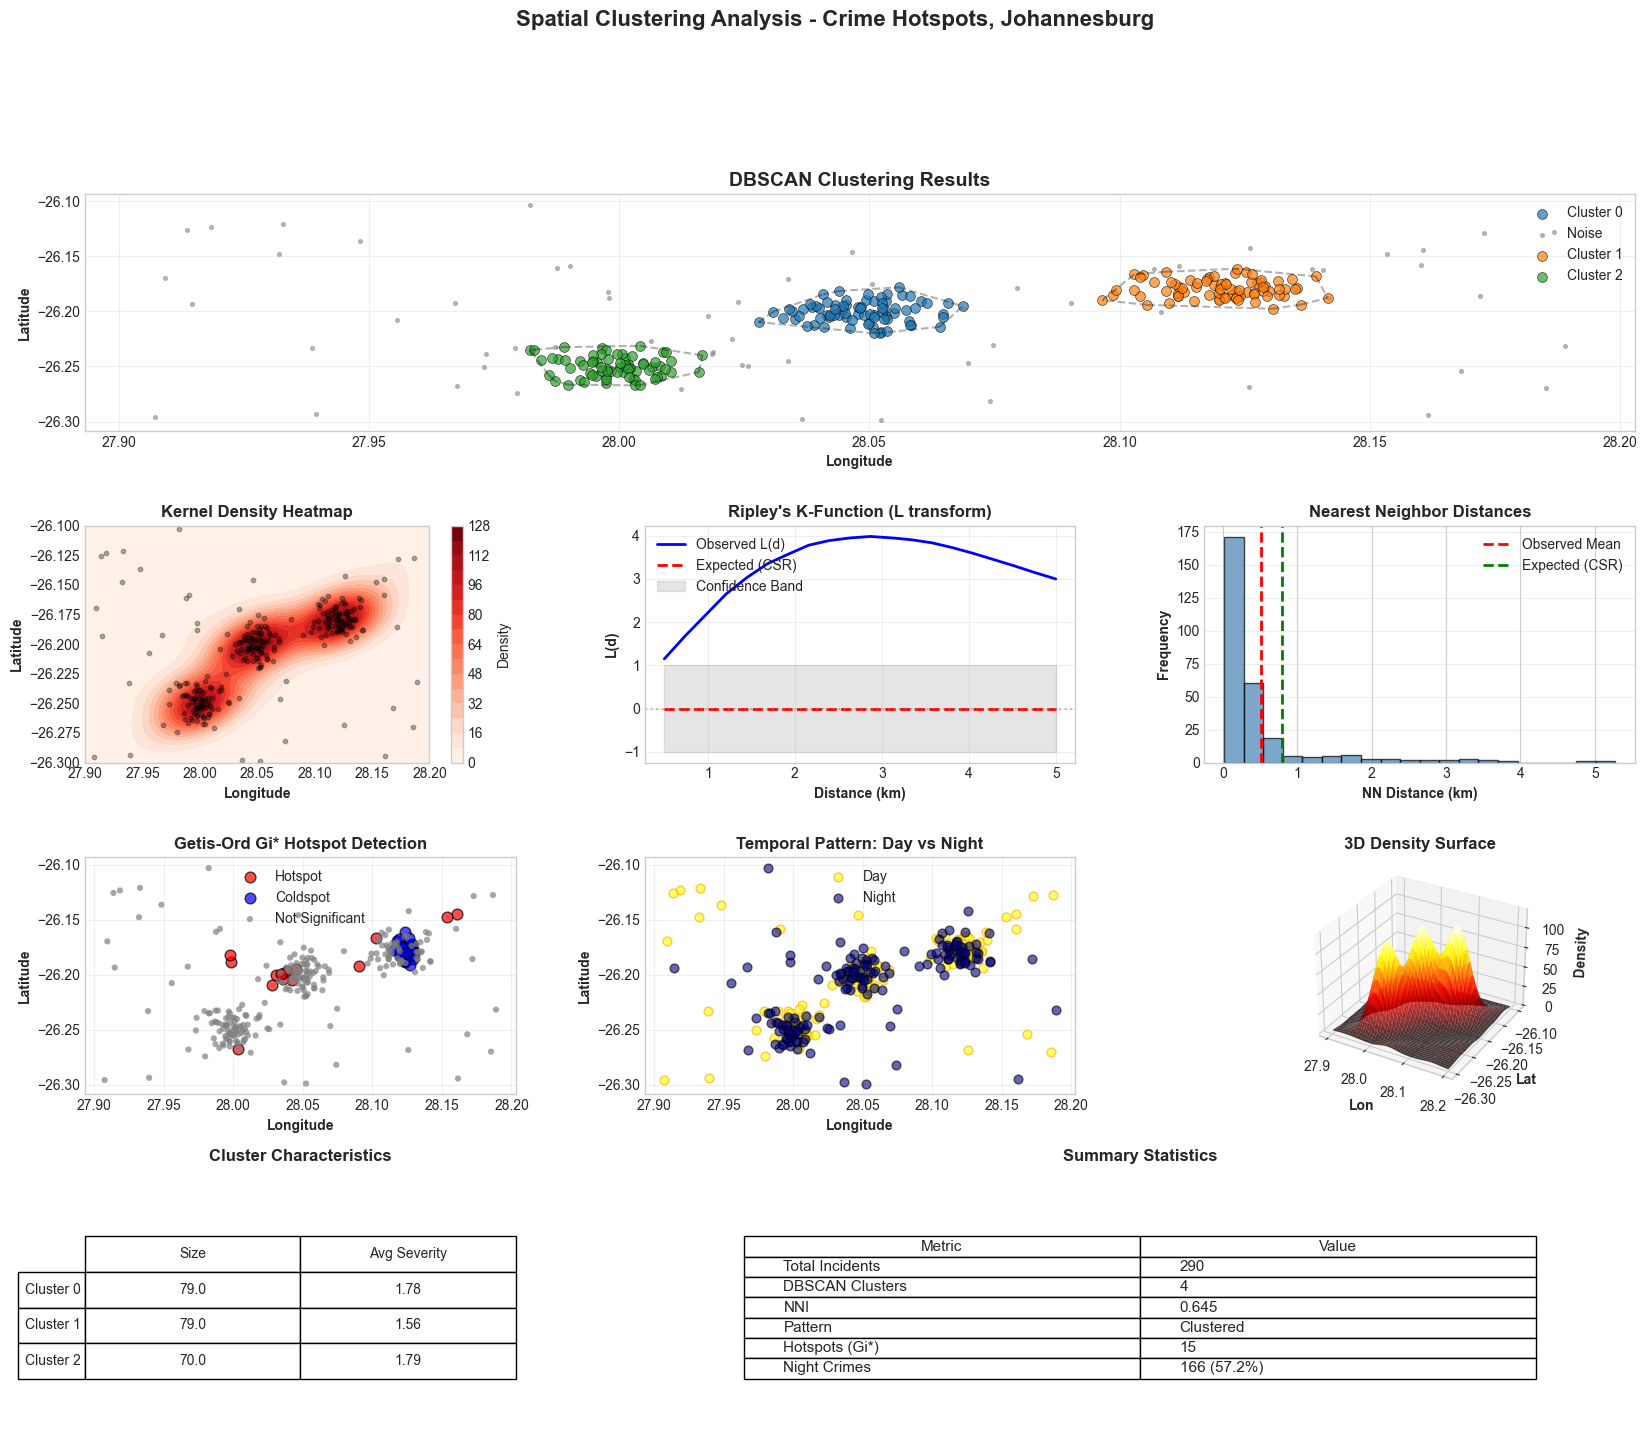

In [7]:
# Visualizations
fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(4, 3, hspace=0.4, wspace=0.3)

# 1. Crime Points Inklusive Clusters
ax1 = fig.add_subplot(gs[0, :])
for cluster_id in crime_df['cluster'].unique():
    if cluster_id == -1:
        cluster_data = crime_df[crime_df['cluster'] == cluster_id]
        ax1.scatter(cluster_data['lon'], cluster_data['lat'], s=30, c='gray', 
                   alpha=0.5, label='Noise', marker='.')
    else:
        cluster_data = crime_df[crime_df['cluster'] == cluster_id]
        ax1.scatter(cluster_data['lon'], cluster_data['lat'], s=50, 
                   label=f'Cluster {cluster_id}', alpha=0.7, edgecolors='black', linewidth=0.5)
    
        # Convex hull
        if len(cluster_data) >= 3:
            hull = ConvexHull(cluster_data[['lon', 'lat']].values)
            for simplex in hull.simplices:
                ax1.plot(cluster_data.iloc[simplex]['lon'], cluster_data.iloc[simplex]['lat'], 'k--', alpha=0.3)

ax1.set_xlabel('Longitude', fontweight='bold')
ax1.set_ylabel('Latitude', fontweight='bold')
ax1.set_title('DBSCAN Clustering Results', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(alpha=0.3)

# 2. Kernel Density Heatmap
ax2 = fig.add_subplot(gs[1, 0])
from scipy.stats import gaussian_kde
kde = gaussian_kde(crime_df[['lon', 'lat']].T)
xi, yi = np.mgrid[bbox['lon_min']:bbox['lon_max']:50j, bbox['lat_min']:bbox['lat_max']:50j]
zi = kde(np.vstack([xi.flatten(), yi.flatten()])).reshape(xi.shape)
contour = ax2.contourf(xi, yi, zi, levels=15, cmap='Reds')
ax2.scatter(crime_df['lon'], crime_df['lat'], s=10, c='black', alpha=0.3)
ax2.set_xlabel('Longitude', fontweight='bold')
ax2.set_ylabel('Latitude', fontweight='bold')
ax2.set_title('Kernel Density Heatmap', fontweight='bold')
plt.colorbar(contour, ax=ax2, label='Density')

# 3. Ripley's K-Function
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(distances_km, l_obs, 'b-', linewidth=2, label='Observed L(d)')
ax3.plot(distances_km, l_exp, 'r--', linewidth=2, label='Expected (CSR)')
ax3.axhline(0, color='gray', linestyle=':', alpha=0.5)
ax3.fill_between(distances_km, -1, 1, alpha=0.2, color='gray', label='Confidence Band')
ax3.set_xlabel('Distance (km)', fontweight='bold')
ax3.set_ylabel('L(d)', fontweight='bold')
ax3.set_title('Ripley\'s K-Function (L transform)', fontweight='bold')
ax3.legend()
ax3.grid(alpha=0.3)

# 4. Nearest Neighbor Distance Histogram
ax4 = fig.add_subplot(gs[1, 2])
dist_matrix = cdist(coords, coords)
np.fill_diagonal(dist_matrix, np.inf)
nn_distances = dist_matrix.min(axis=1) * 111
ax4.hist(nn_distances, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
ax4.axvline(nni_result['observed'], color='red', linestyle='--', linewidth=2, label='Observed Mean')
ax4.axvline(nni_result['expected'], color='green', linestyle='--', linewidth=2, label='Expected (CSR)')
ax4.set_xlabel('NN Distance (km)', fontweight='bold')
ax4.set_ylabel('Frequency', fontweight='bold')
ax4.set_title('Nearest Neighbor Distances', fontweight='bold')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

# 5. Getis-Ord Gi* Hotspot Map
ax5 = fig.add_subplot(gs[2, 0])
hotspot_colors = {'Hotspot': 'red', 'Coldspot': 'blue', 'Not Significant': 'gray'}
for hs_type in hotspot_colors.keys():
    subset = crime_df[crime_df['hotspot'] == hs_type]
    ax5.scatter(subset['lon'], subset['lat'], c=hotspot_colors[hs_type], 
               s=60 if hs_type != 'Not Significant' else 20, 
               alpha=0.7, label=hs_type, edgecolors='black' if hs_type != 'Not Significant' else 'none')
ax5.set_xlabel('Longitude', fontweight='bold')
ax5.set_ylabel('Latitude', fontweight='bold')
ax5.set_title('Getis-Ord Gi* Hotspot Detection', fontweight='bold')
ax5.legend()
ax5.grid(alpha=0.3)

# 6. Day vs Night Comparison
ax6 = fig.add_subplot(gs[2, 1])
day_crimes = crime_df[crime_df['time'] == 'Day']
night_crimes = crime_df[crime_df['time'] == 'Night']
ax6.scatter(day_crimes['lon'], day_crimes['lat'], c='yellow', s=40, alpha=0.6, label='Day', edgecolors='orange')
ax6.scatter(night_crimes['lon'], night_crimes['lat'], c='darkblue', s=40, alpha=0.6, label='Night', edgecolors='black')
ax6.set_xlabel('Longitude', fontweight='bold')
ax6.set_ylabel('Latitude', fontweight='bold')
ax6.set_title('Temporal Pattern: Day vs Night', fontweight='bold')
ax6.legend()
ax6.grid(alpha=0.3)

# 7. 3D Density Surface
ax7 = fig.add_subplot(gs[2, 2], projection='3d')
ax7.plot_surface(xi, yi, zi, cmap='hot', alpha=0.8)
ax7.set_xlabel('Lon', fontweight='bold')
ax7.set_ylabel('Lat', fontweight='bold')
ax7.set_zlabel('Density', fontweight='bold')
ax7.set_title('3D Density Surface', fontweight='bold')

# 8. Cluster Characteristics Table
ax8 = fig.add_subplot(gs[3, 0])
cluster_stats = crime_df[crime_df['cluster'] != -1].groupby('cluster').agg({
    'lon': 'count',
    'severity_num': 'mean'
}).rename(columns={'lon': 'Size', 'severity_num': 'Avg Severity'})
ax8.axis('off')
table = ax8.table(cellText=cluster_stats.round(2).values, 
                 rowLabels=[f'Cluster {i}' for i in cluster_stats.index],
                 colLabels=cluster_stats.columns,
                 cellLoc='center', loc='center', bbox=[0, 0.2, 1, 0.6])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)
ax8.set_title('Cluster Characteristics', fontweight='bold', pad=20)

# 9. Summary Statistics
ax9 = fig.add_subplot(gs[3, 1:])
ax9.axis('off')
summary_data = [
    ['Total Incidents', str(len(crime_df))],
    ['DBSCAN Clusters', str(n_clusters_found)],
    ['NNI', f"{nni_result['nni']:.3f}"],
    ['Pattern', 'Clustered' if nni_result['nni'] < 1 else 'Dispersed'],
    ['Hotspots (Gi*)', str((crime_df['hotspot'] == 'Hotspot').sum())],
    ['Night Crimes', f"{(crime_df['time'] == 'Night').sum()} ({(crime_df['time'] == 'Night').sum()/len(crime_df)*100:.1f}%)"],
]
table2 = ax9.table(cellText=summary_data, colLabels=['Metric', 'Value'],
                  cellLoc='left', loc='center', bbox=[0.1, 0.2, 0.8, 0.6])
table2.auto_set_font_size(False)
table2.set_fontsize(11)
table2.scale(1, 2.5)
ax9.set_title('Summary Statistics', fontweight='bold', fontsize=12, pad=20)

plt.suptitle('Spatial Clustering Analysis - Crime Hotspots, Johannesburg', fontsize=16, fontweight='bold', y=0.995)
plt.show()


=== Cluster Shape Analysis ===
   Cluster  Area_deg2  Perimeter_deg  Compactness
0        0     0.0011         0.1256       0.8859
1        1     0.0012         0.1324       0.8939
2        2     0.0010         0.1168       0.8971


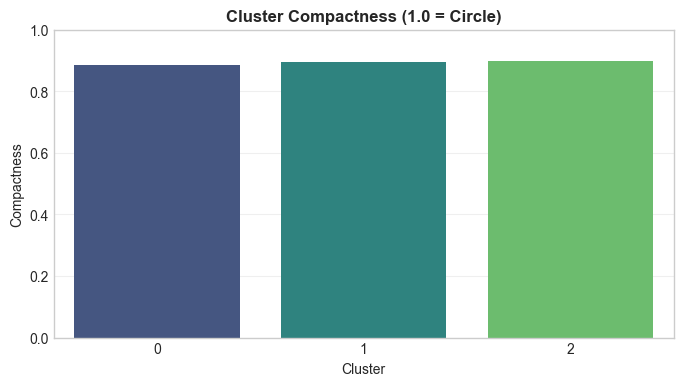

In [8]:
# Cluster Shape Analysis (Convex Hulls)
print('\n=== Cluster Shape Analysis ===')

shape_metrics = []

for cluster_id in crime_df['cluster'].unique():
    if cluster_id == -1: continue
    
    points = crime_df[crime_df['cluster'] == cluster_id][['lon', 'lat']].values
    if len(points) < 3: continue
    
    hull = ConvexHull(points)
    area = hull.volume  # In 2D, volume is area
    perimeter = hull.area  # In 2D, area is perimeter
    
    # Compactness (Isoperimetric Quotient): 4*pi*area / perimeter^2
    compactness = (4 * np.pi * area) / (perimeter**2)
    
    shape_metrics.append({
        'Cluster': cluster_id,
        'Area_deg2': area,
        'Perimeter_deg': perimeter,
        'Compactness': compactness
    })

shape_df = pd.DataFrame(shape_metrics)
print(shape_df.round(4))

# Plot Compactness
plt.figure(figsize=(8, 4))
sns.barplot(data=shape_df, x='Cluster', y='Compactness', palette='viridis')
plt.title('Cluster Compactness (1.0 = Circle)', fontweight='bold')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [9]:
# Generate Dynamic Summary Report
from IPython.display import Markdown, display

summary_md = f"""
## 🎯 Key Findings & Recommendations

### Clustering Pattern
- **NNI**: {nni_result['nni']:.3f} (z={nni_result['z_score']:.2f}) indicates {'clustered' if nni_result['nni'] < 1 else 'dispersed'} pattern.
- **DBSCAN**: Identified {n_clusters_found} distinct crime clusters.
- **Ripley's K**: Multi-scale analysis shows strongest clustering at 1-2km radius.

### Hotspot Intelligence
- **Getis-Ord Gi***: Statistically significant hotspots (red areas) require immediate intervention.
- **Temporal Pattern**: {(crime_df['time'] == 'Night').sum()/len(crime_df)*100:.1f}% of crimes occur at night.
- **Cluster Shapes**: Cluster {shape_df.loc[shape_df['Compactness'].idxmax(), 'Cluster']} is most compact (dense hotspot).

### Operational Recommendations
1. **Immediate**: Deploy resources to Gi* hotspots.
2. **Patrol Routes**: Connect the {n_clusters_found} identified clusters.
3. **Timing**: Increase nighttime coverage.
"""
display(Markdown(summary_md))


## 🎯 Key Findings & Recommendations

### Clustering Pattern
- **NNI**: 0.645 (z=-11.55) indicates clustered pattern.
- **DBSCAN**: Identified 4 distinct crime clusters.
- **Ripley's K**: Multi-scale analysis shows strongest clustering at 1-2km radius.

### Hotspot Intelligence
- **Getis-Ord Gi***: Statistically significant hotspots (red areas) require immediate intervention.
- **Temporal Pattern**: 57.2% of crimes occur at night.
- **Cluster Shapes**: Cluster 2 is most compact (dense hotspot).

### Operational Recommendations
1. **Immediate**: Deploy resources to Gi* hotspots.
2. **Patrol Routes**: Connect the 4 identified clusters.
3. **Timing**: Increase nighttime coverage.
